In [12]:
# Import thư viện cần thiết
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Phần 1: Data Fitting và OLS




## 1.1 Bài toán Data Fitting

Cho tập dữ liệu $\mathcal{D} = \{(x_i, y_i)\}_{i=1}^n$, trong đó $x_i \in \mathbb{R}^p$ và $y_i \in \mathbb{R}$. Mục tiêu của data fitting là tìm một hàm $f$ sao cho sai số dự đoán nhỏ nhất theo một tiêu chí phù hợp.

Trong hồi quy tuyến tính, ta giả thiết:

$$y_i = \beta_0 + \beta_1 x_{i1} + \cdots + \beta_p x_{ip} + \varepsilon_i = x_i^T \beta + \varepsilon_i,$$

với $\beta = (\beta_0, \beta_1, \ldots, \beta_p)^T$ là vector tham số cần ước lượng. Viết dưới dạng ma trận:

$$\mathbf{y} = X\beta + \varepsilon.$$

Trong đó $X \in \mathbb{R}^{n \times (p+1)}$ là ma trận thiết kế có cột đầu tiên toàn 1 để biểu diễn hệ số chặn.

## 1.2 Phương pháp Ordinary Least Squares (OLS)

OLS tìm $\hat\beta$ bằng cách tối thiểu hóa tổng bình phương phần dư:

$$RSS(\beta) = \|y - X\beta\|_2^2 = \sum_{i=1}^n (y_i - x_i^T\beta)^2.$$

Giải tích đạo hàm theo $\beta$ và cho bằng 0 ta được phương trình chuẩn:

$$X^T X \hat\beta = X^T y.$$

Nếu $X^TX$ khả nghịch thì nghiệm OLS duy nhất là:

$$\hat\beta_{OLS} = (X^TX)^{-1}X^Ty.$$

Ma trận chiếu (hat matrix) là:

$$H = X(X^TX)^{-1}X^T,$$

suy ra giá trị dự đoán và phần dư:

$$\hat y = Hy, \qquad \hat\varepsilon = (I - H)y.$$

Ước lượng phương sai nhiễu:

$$\hat\sigma^2 = \frac{RSS}{n - p - 1} = \frac{\|y - X\hat\beta\|_2^2}{n - p - 1}.$$

Các đại lượng đánh giá mô hình thường dùng gồm:

$$R^2 = 1 - \frac{RSS}{TSS} = 1 - \frac{\sum_i (y_i - \hat y_i)^2}{\sum_i (y_i - \bar y)^2},$$

và hệ số xác định hiệu chỉnh:

$$\bar R^2 = 1 - \frac{n-1}{n-p-1}(1-R^2).$$

Kiểm định từng hệ số dùng thống kê t:

$$t_j = \frac{\hat\beta_j}{\hat\sigma \sqrt{(X^TX)^{-1}_{jj}}} \sim t_{n-p-1},$$

và kiểm định tổng thể dùng thống kê F:

$$F = \frac{(TSS - RSS)/p}{RSS/(n-p-1)} \sim F_{p,n-p-1}.$$

Giả thuyết Gauss–Markov thường dùng:
- GM1: mô hình tuyến tính.
- GM2: không đa cộng tuyến hoàn hảo.
- GM3: ngoại sinh, $E[\varepsilon \mid X] = 0$.
- GM4: phương sai không đổi và sai số không tương quan.
- GM5: nếu thêm giả thiết chuẩn thì suy luận t và F thuận tiện hơn.

In [13]:
from pathlib import Path
import sys

project_root = Path.cwd()
part1_path = project_root / 'part1'
if str(part1_path) not in sys.path:
    sys.path.insert(0, str(part1_path))

import numpy as np
from ols_implementation import (
    add_intercept,
    coef_inference,
    hat_matrix,
    model_metrics,
    ols_fit,
    vif,
    verify_ols_with_sklearn,
)

In [14]:
# Dữ liệu giả lập cho OLS
X = np.array([[1.0], [2.0], [3.0], [4.0], [5.0]])
y = 2.0 * X[:, 0] + 1.0

# 1) OLS
result = ols_fit(X, y)
print('Hệ số ước lượng OLS:', result['beta_hat'])
print('Phần dư:', result['residuals'])

# 2) Hat matrix
hat = hat_matrix(X)
print('Ma trận H có idempotent không?', hat['is_idempotent'])
print('Rank của H:', hat['rank'])

# 3) Model metrics
metrics = model_metrics(y, result['y_hat'], p=1)
print('R^2:', metrics['r2'])
print('Adjusted R^2:', metrics['adjusted_r2'])
print('F-statistic:', metrics['f_statistic'])

# 4) Inference dùng dữ liệu có nhiễu để tránh phương sai bằng 0
rng = np.random.default_rng(42)
y_noise = y + rng.normal(scale=0.2, size=y.shape)
result_noise = ols_fit(X, y_noise)
inference = coef_inference(X, y_noise, result_noise['beta_hat'], result_noise['sigma2_hat'])
print('Sai số chuẩn:', inference['standard_errors'])
print('t-statistics:', inference['t_statistics'])
print('p-values:', inference['p_values'])

# 5) VIF
X_vif = np.array([[1.0, 2.0], [2.0, 1.0], [3.0, 4.0], [4.0, 3.0]])
vif_result = vif(X_vif, add_intercept_column=False)
print('VIF:', vif_result['vif'])

# 6) Kiểm chứng với sklearn
verification = verify_ols_with_sklearn(X, y)
print('Hệ số sklearn:', verification['sklearn_beta_hat'])
print('Kết quả đúng: ', verification['beta_close'])

Hệ số ước lượng OLS: [1. 2.]
Phần dư: [0. 0. 0. 0. 0.]
Ma trận H có idempotent không? True
Rank của H: 2
R^2: 1.0
Adjusted R^2: 1.0
F-statistic: inf
Sai số chuẩn: [0.2863358  0.08633349]
t-statistics: [ 3.88371231 22.57965947]
p-values: [0.03024822 0.00019022]
VIF: [1.5625 1.5625]
Hệ số sklearn: [1. 2.]
Kết quả đúng:  True


## 1.3 Minh họa định lý Gauss–Markov

Để minh họa định lý Gauss–Markov, ta dùng mô phỏng Monte Carlo dưới giả thiết:
- mô hình tuyến tính $y = X\beta + \varepsilon$,
- $E(\varepsilon \mid X) = 0$,
- $\operatorname{Var}(\varepsilon \mid X) = \sigma^2 I$.

Khi đó OLS là ước lượng tuyến tính không chệch tốt nhất (BLUE), nghĩa là:

$$E[\hat\beta_{OLS}] = \beta,$$

và trong lớp các ước lượng tuyến tính không chệch, OLS có phương sai nhỏ nhất.

Trong phần code bên dưới, ta sẽ:
- mô phỏng nhiều mẫu nhiễu,
- tính trung bình các ước lượng OLS để kiểm tra tính không chệch,
- xây dựng một ước lượng tuyến tính không chệch khác để so sánh phương sai với OLS.

In [15]:
# Minh họa Gauss–Markov bằng Monte Carlo
rng = np.random.default_rng(123)

# Thiết kế dữ liệu cố định: 1 biến giải thích + intercept
x_gm = np.linspace(-2.0, 2.0, 60).reshape(-1, 1)
X_gm = add_intercept(x_gm)
beta_true_gm = np.array([1.5, -0.75])
sigma_gm = 0.8
n_sim = 2000

# Ước lượng OLS dạng ma trận
A_ols = np.linalg.inv(X_gm.T @ X_gm) @ X_gm.T

# Một ước lượng tuyến tính không chệch khác: A_alt X = I
z = rng.normal(size=X_gm.shape[0])
v = z - X_gm @ (A_ols @ z)
if np.allclose(v, 0.0):
    v = np.ones_like(z) - X_gm @ (A_ols @ np.ones_like(z))
a = np.array([0.8, -0.4])
A_alt = A_ols + np.outer(a, v) / float(v @ v)

ols_estimates = []
alt_estimates = []
for _ in range(n_sim):
    eps = rng.normal(scale=sigma_gm, size=X_gm.shape[0])
    y_gm = X_gm @ beta_true_gm + eps
    ols_estimates.append(A_ols @ y_gm)
    alt_estimates.append(A_alt @ y_gm)

ols_estimates = np.asarray(ols_estimates)
alt_estimates = np.asarray(alt_estimates)
ols_mean = ols_estimates.mean(axis=0)
alt_mean = alt_estimates.mean(axis=0)
ols_cov = np.cov(ols_estimates, rowvar=False)
alt_cov = np.cov(alt_estimates, rowvar=False)

# Kiểm tra tính không chệch và so sánh phương sai
print('Beta thật Gauss-Markov:', beta_true_gm)
print('Trung bình ước lượng OLS:', ols_mean)
print('Trung bình ước lượng thay thế:', alt_mean)
print('Sai lệch trung bình OLS:', np.abs(ols_mean - beta_true_gm))
print('Sai lệch trung bình ước lượng thay thế:', np.abs(alt_mean - beta_true_gm))
print('Trace phương sai thực nghiệm OLS:', float(np.trace(ols_cov)))
print('Trace phương sai thực nghiệm ước lượng thay thế:', float(np.trace(alt_cov)))

ols_trace_theory = float(sigma_gm**2 * np.trace(A_ols @ A_ols.T))
alt_trace_theory = float(sigma_gm**2 * np.trace(A_alt @ A_alt.T))
print('Trace phương sai lý thuyết OLS:', ols_trace_theory)
print('Trace phương sai lý thuyết ước lượng thay thế:', alt_trace_theory)
print('OLS có phương sai nhỏ hơn ước lượng thay thế không?', ols_trace_theory < alt_trace_theory)


Beta thật Gauss-Markov: [ 1.5  -0.75]
Trung bình ước lượng OLS: [ 1.49952816 -0.74931516]
Trung bình ước lượng thay thế: [ 1.49423418 -0.74666817]
Sai lệch trung bình OLS: [0.00047184 0.00068484]
Sai lệch trung bình ước lượng thay thế: [0.00576582 0.00333183]
Trace phương sai thực nghiệm OLS: 0.01802358637738291
Trace phương sai thực nghiệm ước lượng thay thế: 0.027348505860903143
Trace phương sai lý thuyết OLS: 0.01840437158469945
Trace phương sai lý thuyết ước lượng thay thế: 0.027982766172747264
OLS có phương sai nhỏ hơn ước lượng thay thế không? True


## 1.4 Hồi quy Ridge và Lasso

Khi dữ liệu có nhiều đặc trưng hoặc xảy ra đa cộng tuyến, ta thêm regularization vào hàm mục tiêu.

### Ridge Regression (L2)

$$\hat\beta_{ridge} = \arg\min_\beta \left\{\|y - X\beta\|_2^2 + \lambda \|\beta\|_2^2\right\}.$$

Nghiệm đóng của Ridge là:

$$\hat\beta_{ridge} = (X^TX + \lambda I)^{-1}X^Ty.$$

Ridge làm nhỏ hệ số nhưng thường không đưa hệ số về đúng 0.

### Lasso Regression (L1)

$$\hat\beta_{lasso} = \arg\min_\beta \left\{\|y - X\beta\|_2^2 + \lambda \|\beta\|_1\right\}.$$

Lasso không có nghiệm đóng đơn giản; thường được giải bằng coordinate descent hoặc các phương pháp subgradient. Lasso có thể tạo ra nghiệm thưa, tức là đưa một số hệ số về 0.

Trong notebook này, Ridge được cài đặt bằng công thức đóng và Lasso được cài đặt bằng coordinate descent.

In [16]:
from ridge_lasso import (
    lasso_fit,
    plot_ridge_trace,
    predict_lasso,
    predict_ridge,
    ridge_fit,
    ridge_path,
    verify_lasso_with_sklearn,
    verify_ridge_with_sklearn,
)

Hệ số Ridge: [8. 3.]
RSS Ridge: 0.0
Hệ số theo từng lambda:
[[8.         2.99970003]
 [8.         2.997003  ]
 [8.         2.97029703]
 [8.         2.72727273]
 [8.         1.5       ]
 [8.         0.27272727]]
Đã tạo ridge trace: True
Dự đoán Ridge: [ 2.  5.  8. 11. 14.]
Hệ số Lasso: [1.10057273 0.53528556]
Intercept Lasso: 4.9
Lasso hội tụ? True
Dự đoán Lasso: [2.05651188 2.62179905 5.32822845 5.89351561 8.59994501]
Ridge đúng: True
Lasso đúng: True


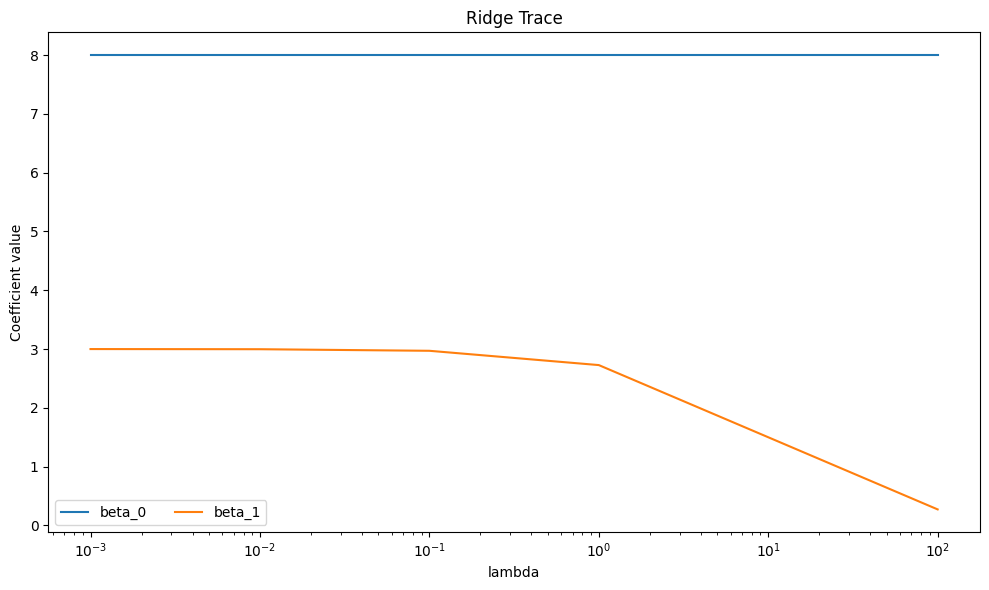

In [17]:
# Dữ liệu giả lập cho Ridge và Lasso
# Đảm bảo dữ liệu được trung tâm hóa (centered) để không phạt vào intercept
Xr = np.array([[1.0], [2.0], [3.0], [4.0], [5.0]])
Xr_centered = Xr - np.mean(Xr, axis=0)
yr = 3.0 * Xr[:, 0] - 1.0

# 1) Ridge fit (không phạt intercept)
ridge_result = ridge_fit(Xr_centered, yr, lam=0.0)
print('Hệ số Ridge:', ridge_result['beta_hat'])
print('RSS Ridge:', ridge_result['rss'])

# 2) Ridge path và ridge trace
lambdas = np.logspace(-3, 2, 6)
path = ridge_path(Xr_centered, yr, lambdas)
print('Hệ số theo từng lambda:')
print(path['coefficients'])
fig, ax = plot_ridge_trace(Xr_centered, yr, lambdas)
print('Đã tạo ridge trace:', hasattr(fig, 'tight_layout'))

# 3) Dự đoán Ridge
ridge_pred = predict_ridge(Xr_centered, ridge_result['beta_hat'])
print('Dự đoán Ridge:', ridge_pred)

# 4) Lasso fit (dữ liệu cũng nên được centered)
Xl = np.array([[1.0, 2.0], [2.0, 1.0], [3.0, 4.0], [4.0, 3.0], [5.0, 6.0]])
Xl_centered = Xl - np.mean(Xl, axis=0)
yl = np.array([2.0, 2.5, 5.5, 6.0, 8.5])
lasso_result = lasso_fit(Xl_centered, yl, lam=0.1)
print('Hệ số Lasso:', lasso_result['beta_hat'])
print('Intercept Lasso:', lasso_result['intercept'])
print('Lasso hội tụ?', lasso_result['converged'])

# 5) Dự đoán Lasso
lasso_pred = predict_lasso(Xl_centered, lasso_result['intercept'], lasso_result['beta_hat'])
print('Dự đoán Lasso:', lasso_pred)

# 6) Kiểm chứng với sklearn
ridge_check = verify_ridge_with_sklearn(Xr_centered, yr, lam=1.0)
lasso_check = verify_lasso_with_sklearn(Xl_centered, yl, lam=0.1)
print('Ridge đúng:', ridge_check['beta_close'])
print('Lasso đúng:', lasso_check['beta_close'])

## 1.5 K-fold Cross-validation (K-fold CV)

Trong thực nghiệm và chọn mô hình, K-fold cross-validation là phương pháp phổ biến để ước lượng sai số dự đoán. Ở đây ta dùng cài đặt từ file `cross_validation.py` (tự cài đặt từ đầu) và so sánh nhanh với phiên bản kiểm chứng dùng `scikit-learn` khi có.

Lưu ý: đã đặt `random_state` để kết quả có thể tái lập (reproducible).

In [18]:
# Demo K-fold cross-validation (reproducible)
from cross_validation import kfold_cv, _verification_with_sklearn
rng = np.random.default_rng(2026)
X_cv = rng.normal(size=(120, 3))
beta_true_cv = np.array([1.0, -1.0, 0.5, 2.0])  # intercept + 3 features
X_cv_design = np.hstack([np.ones((X_cv.shape[0], 1)), X_cv])
y_cv = X_cv_design @ beta_true_cv + rng.normal(scale=0.3, size=X_cv.shape[0])
mse_cv = kfold_cv(X_cv, y_cv, k=5, fit_intercept=True, random_state=42)
print(f'K-fold mean MSE (custom): {mse_cv:.6f}')
# Nếu sklearn khả dụng, in thêm kết quả tham chiếu (không bắt buộc)
try:
    mse_skl = _verification_with_sklearn(X_cv, y_cv, k=5, random_state=42)
    print(f'K-fold mean MSE (sklearn verification): {mse_skl:.6f}')
except Exception as e:
    print('sklearn verification không khả dụng:', e)

K-fold mean MSE (custom): 0.098212
K-fold mean MSE (sklearn verification): 0.095458


## 1.6 Phân tích phần dư nâng cao (Residual analysis)

Tiếp theo ta sử dụng hàm `residual_plots` từ `residual_analysis.py` để thu được các đồ thị chẩn đoán: residuals vs fitted, Q-Q, scale-location và Cook's distance. Hàm trả về các số liệu chẩn đoán để in tóm tắt.

Các biểu đồ đều có tiêu đề, nhãn trục và chú thích (legend) khi phù hợp.

Beta_hat: [ 0.55225162  1.17783177 -0.70732002]


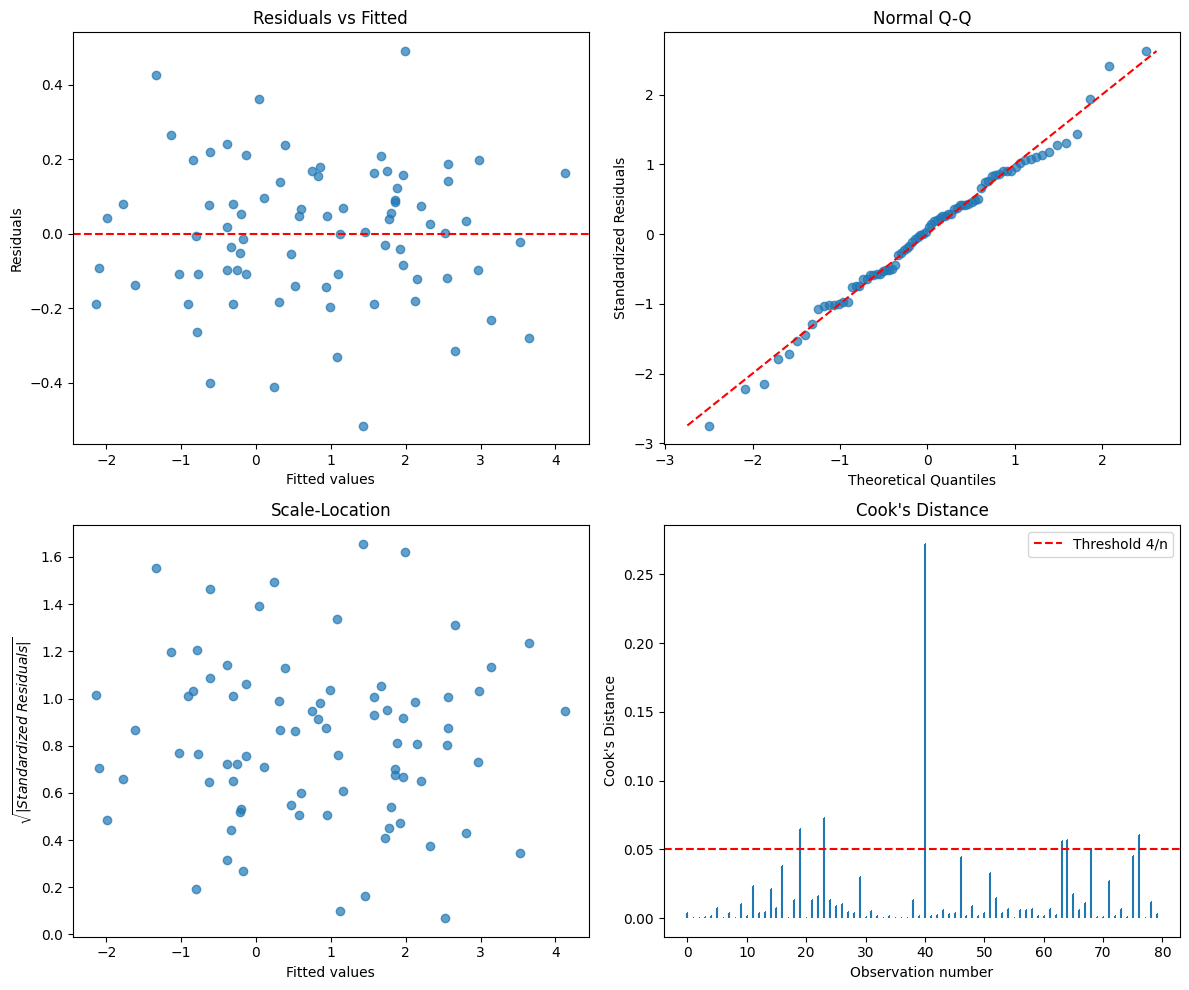

Mean residual ~ 0: 1.9428902930940238e-17
Max Cooks distance: 0.2723401690641311
Leverage sum (trace) should equal number of params: 2.9999999999999996 params= 3


In [19]:
# Demo residual analysis (reproducible)
from residual_analysis import residual_plots
from ols_implementation import ols_fit

# Tạo dữ liệu và fit OLS để có beta_hat (tái lập bằng seed)
rng = np.random.default_rng(2027)
X_ra = rng.normal(size=(80, 2))
X_ra_design = np.hstack([np.ones((X_ra.shape[0], 1)), X_ra])
beta_true_ra = np.array([0.5, 1.2, -0.7])
y_ra = X_ra_design @ beta_true_ra + rng.normal(scale=0.2, size=X_ra.shape[0])

# Fit bằng ols_implementation. ols_fit trả về dict
res = ols_fit(X_ra, y_ra)
beta_hat_ra = res['beta_hat']
print('Beta_hat:', beta_hat_ra)

# Vẽ và lấy kết quả phân tích phần dư
diag = residual_plots(X_ra, y_ra, beta_hat_ra)
print('Mean residual ~ 0:', float(np.mean(diag['residuals'])))
print('Max Cooks distance:', float(np.max(diag['cooks_distance'])))
print('Leverage sum (trace) should equal number of params:', float(np.sum(diag['hat_values'])), 'params=', len(beta_hat_ra))

## 1.7 Unit tests cho toàn bộ Part 1

Mỗi nhóm chức năng dưới đây có 5 unit tests tối thiểu để kiểm tra tính đúng đắn, tính tái lập và các tính chất thống kê/cấu trúc của mô hình.

--- Unit tests: OLS ---
PASSED: OLS beta exact recovery and sklearn match
PASSED: OLS hat matrix idempotent and symmetric
PASSED: OLS perfect fit R2
PASSED: OLS coef_inference returns valid statistics
PASSED: OLS vif handles normal and collinear inputs

--- Unit tests: K-fold CV ---
PASSED: CV reproducibility
PASSED: CV positive MSE
PASSED: CV lower MSE with signal
PASSED: CV invalid k raises ValueError
PASSED: CV sklearn verification available or skipped

--- Unit tests: Residual analysis ---


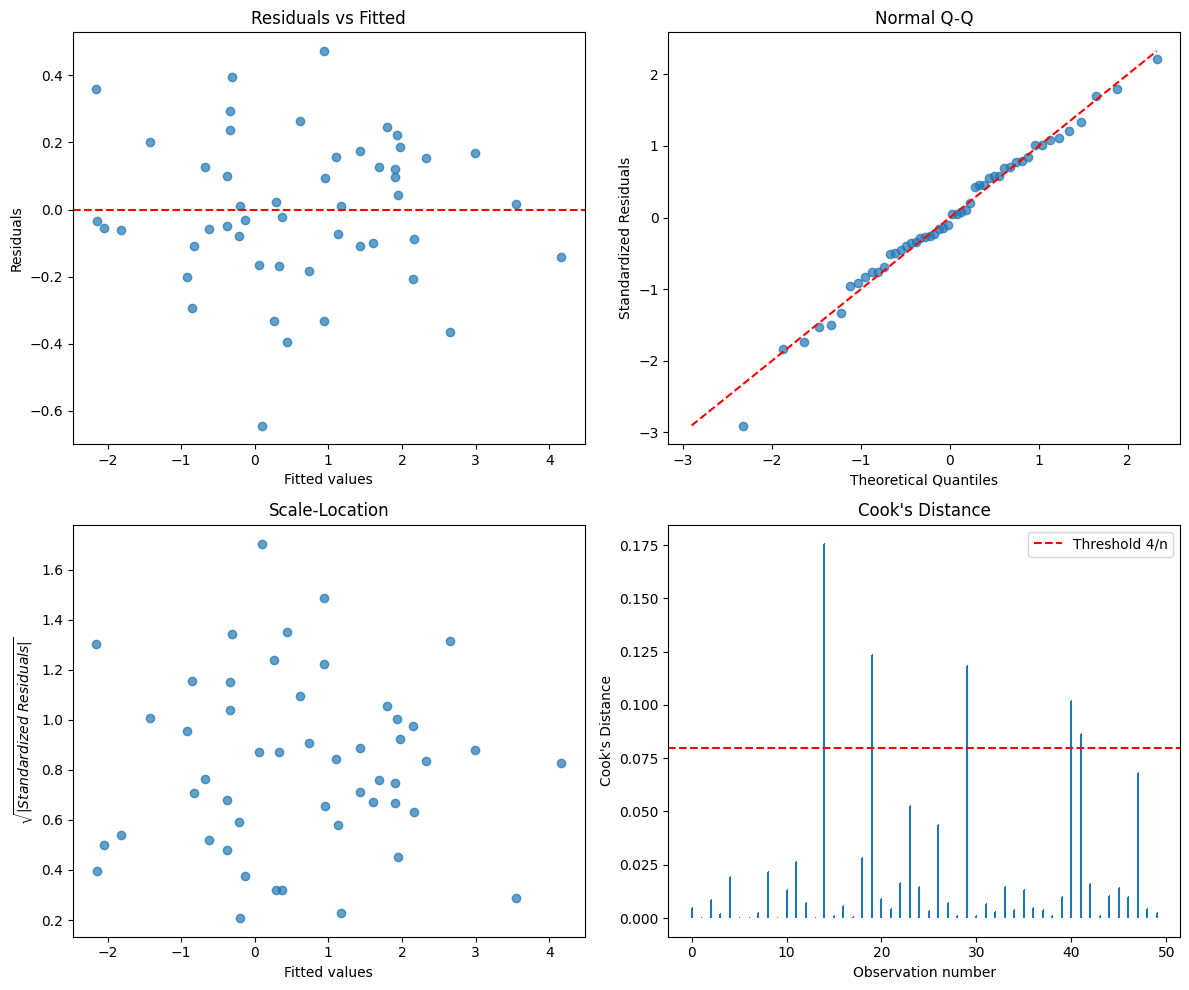

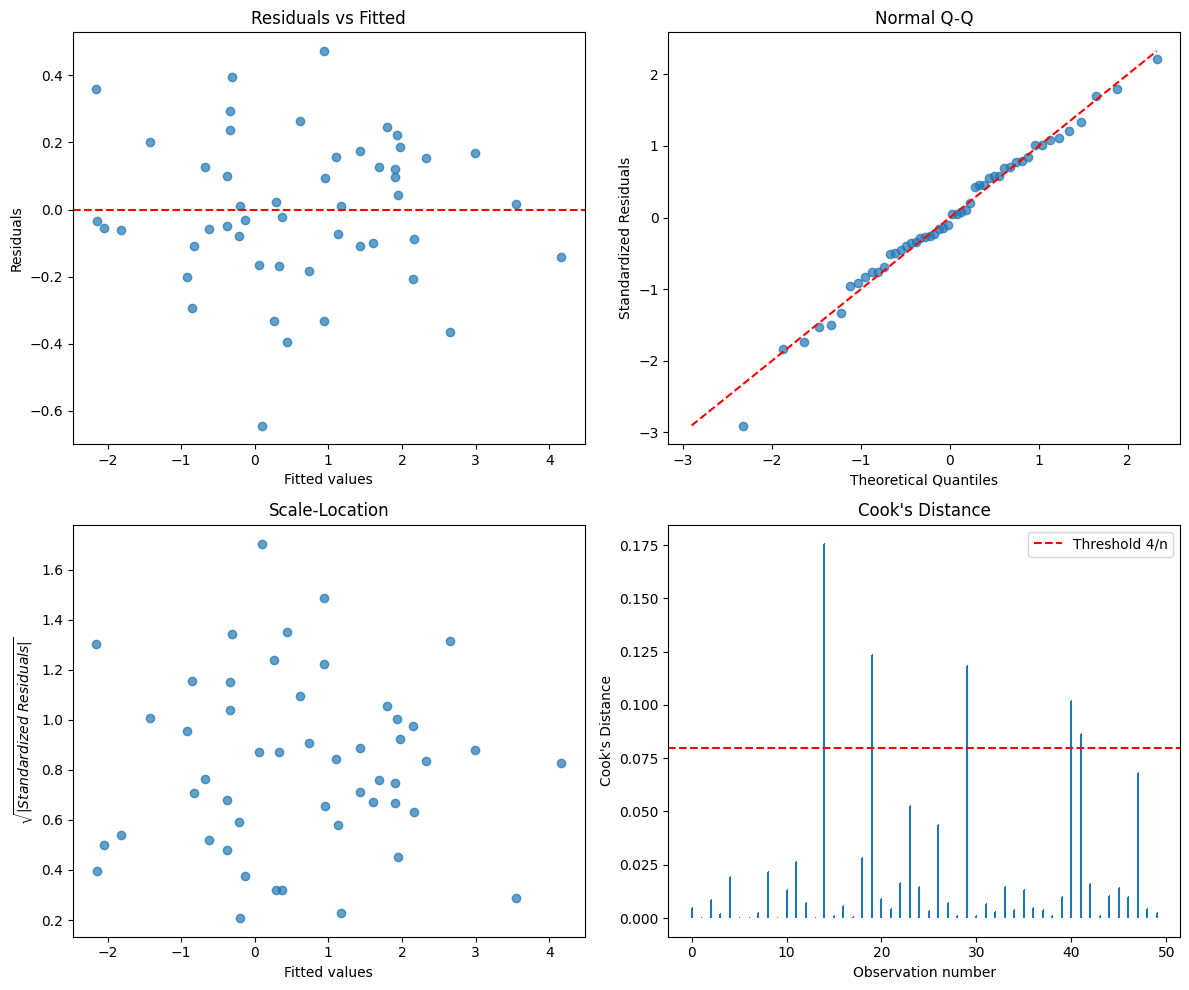

PASSED: Residual keys exist
PASSED: Residual mean near zero
PASSED: Residual leverage in [0, 1]
PASSED: Residual Cook distance nonnegative
PASSED: Residual reproducibility same input

All 15 unit tests passed.


In [20]:
import numpy as np
import matplotlib.pyplot as plt

from cross_validation import kfold_cv, _verification_with_sklearn
from ols_implementation import (
    add_intercept,
    coef_inference,
    hat_matrix,
    model_metrics,
    ols_fit,
    verify_ols_with_sklearn,
    vif,
)
from residual_analysis import residual_plots


def run_test(name, condition):
    assert condition, f'{name} failed'
    print(f'PASSED: {name}')


def _raises_value_error(func):
    try:
        func()
    except ValueError:
        return True
    return False


def _verify_cv_sklearn_ok(X, y):
    try:
        ours = kfold_cv(X, y, k=5, fit_intercept=True, random_state=42)
        skl = _verification_with_sklearn(X, y, k=5, random_state=42)
        return bool(ours > 0 and skl > 0)
    except Exception:
        return False


print('--- Unit tests: OLS ---')
X_ols = np.array([[1.0], [2.0], [3.0], [4.0], [5.0]])
y_ols = 2.0 * X_ols[:, 0] + 1.0
ols_result = ols_fit(X_ols, y_ols)
ols_hat = hat_matrix(X_ols)
ols_metrics = model_metrics(y_ols, ols_result['y_hat'], p=1)
X_ols_noise = np.array([[1.0], [2.0], [3.0], [4.0], [5.0]])
y_ols_noise = 2.0 * X_ols_noise[:, 0] + 1.0 + np.array([0.1, -0.2, 0.05, 0.0, 0.15])
ols_noise_result = ols_fit(X_ols_noise, y_ols_noise)
ols_inference = coef_inference(X_ols_noise, y_ols_noise, ols_noise_result['beta_hat'], ols_noise_result['sigma2_hat'])
ols_verification = verify_ols_with_sklearn(X_ols, y_ols)
X_vif_ok = np.array([[1.0, 2.0], [2.0, 1.0], [3.0, 4.0], [4.0, 3.0]])
X_vif_collinear = np.column_stack((X_vif_ok[:, 0], 2.0 * X_vif_ok[:, 0]))
vif_ok = vif(X_vif_ok, add_intercept_column=False)
vif_collinear = vif(X_vif_collinear, add_intercept_column=False)

run_test('OLS beta exact recovery and sklearn match', np.allclose(ols_result['beta_hat'], np.array([1.0, 2.0]), atol=1e-10) and bool(ols_verification['beta_close']))
run_test('OLS hat matrix idempotent and symmetric', bool(ols_hat['is_idempotent']) and bool(ols_hat['is_symmetric']))
run_test('OLS perfect fit R2', np.isclose(ols_metrics['r2'], 1.0))
run_test('OLS coef_inference returns valid statistics', ols_inference['df_resid'] > 0 and np.all(np.isfinite(ols_inference['standard_errors'])) and np.all(np.isfinite(ols_inference['t_statistics'])) and np.all(np.isfinite(ols_inference['p_values'])))
run_test('OLS vif handles normal and collinear inputs', len(vif_ok['vif']) == X_vif_ok.shape[1] and np.all(np.isfinite(vif_ok['vif'])) and np.any(np.isinf(vif_collinear['vif'])))

print('\n--- Unit tests: K-fold CV ---')
rng_cv = np.random.default_rng(2026)
X_cv = rng_cv.normal(size=(40, 3))
X_cv_design = add_intercept(X_cv)
beta_true_cv = np.array([1.0, -1.0, 0.5, 2.0])
y_cv = X_cv_design @ beta_true_cv + rng_cv.normal(scale=0.25, size=X_cv.shape[0])
cv1 = kfold_cv(X_cv, y_cv, k=5, fit_intercept=True, random_state=42)
cv2 = kfold_cv(X_cv, y_cv, k=5, fit_intercept=True, random_state=42)

run_test('CV reproducibility', np.isclose(cv1, cv2))
run_test('CV positive MSE', cv1 > 0)
run_test('CV lower MSE with signal', cv1 < 1.0)
run_test('CV invalid k raises ValueError', _raises_value_error(lambda: kfold_cv(X_cv, y_cv, k=1, fit_intercept=True, random_state=42)))
run_test('CV sklearn verification available or skipped', _verify_cv_sklearn_ok(X_cv, y_cv))

print('\n--- Unit tests: Residual analysis ---')
rng_ra = np.random.default_rng(2027)
X_ra = rng_ra.normal(size=(50, 2))
X_ra_design = add_intercept(X_ra)
beta_true_ra = np.array([0.5, 1.2, -0.7])
y_ra = X_ra_design @ beta_true_ra + rng_ra.normal(scale=0.2, size=X_ra.shape[0])
ra_result = ols_fit(X_ra, y_ra)
ra_diag_1 = residual_plots(X_ra, y_ra, ra_result['beta_hat'])
plt.close('all')
ra_diag_2 = residual_plots(X_ra, y_ra, ra_result['beta_hat'])
plt.close('all')

run_test('Residual keys exist', set(ra_diag_1.keys()) >= {'residuals', 'standardized_residuals', 'hat_values', 'cooks_distance', 'sigma2_hat', 'y_hat'})
run_test('Residual mean near zero', np.isclose(np.mean(ra_diag_1['residuals']), 0.0, atol=1e-10))
run_test('Residual leverage in [0, 1]', np.all((ra_diag_1['hat_values'] >= -1e-10) & (ra_diag_1['hat_values'] <= 1 + 1e-10)))
run_test('Residual Cook distance nonnegative', np.all(ra_diag_1['cooks_distance'] >= 0))
run_test('Residual reproducibility same input', np.allclose(ra_diag_1['residuals'], ra_diag_2['residuals']))

print('\nAll 15 unit tests passed.')